# TP CC

## 1. Problème aux limites 1D

### Nous avons ici une condition limite périodique donc nous utiliseron une rfft.
### $-u''(x) + u(x) = f(x)$
### $u(0) = u(1), u'(0) = u'(1)$

### 1.1 Solution exacte.

###     On peut choisir cette fonction $u(x)$ qui respecte les conditions limites $u(x) = sin(2\pi x)$
$f(x) = 4\pi^2 sin(2\pi x) + sin(2\pi x)$

$Vect(\phi_k, ~0\le k<N)$ est une base orthogonale de vecteurs propres pour les opérateurs de dérivation avec condition limite périodique. En dimension supérieure, c'est encore vrai; pour d'autres conditions limites, Dirichlet et Neumann, c'est encore vrai 

### Décomposition de la base rfft : $\phi_0=\frac 1 {N}$, $\phi_1(x)=\frac 2 {N} \cos(2\pi\frac x L)$, $\phi_2(x)=-\frac 2 {N} \sin(2\pi\frac x L)$, $\cdots$, $\phi_{N-2}(x)=-\frac 2 {N} \sin(2\pi\frac{N-2}2\frac x L)$, $\phi_{N-1}(x)=\frac 1 {N} \cos(2\pi\frac N 2\frac x L)$, associée à la fonction "rfft" de scipy.

### Décomposition de f dans cette bas :
### $Pnf = \sum\limits_{k}{(\lambda_k+1)\hat u_k \phi_k}$
### Avec $\lambda_k = (\frac{2\pi k}{2L})^2$ quand $k = 2k$
### Et $\lambda_k = (\frac{2\pi (k+1)}{2L})^2$ quand $k = 2k+1$
### Donc $\hat u_k = \frac{\hat f_k}{\lambda _k + 1}$


On calcule les $\lambda_k$ avec le coeff devant la moins dérivée seconde de $\phi_k$

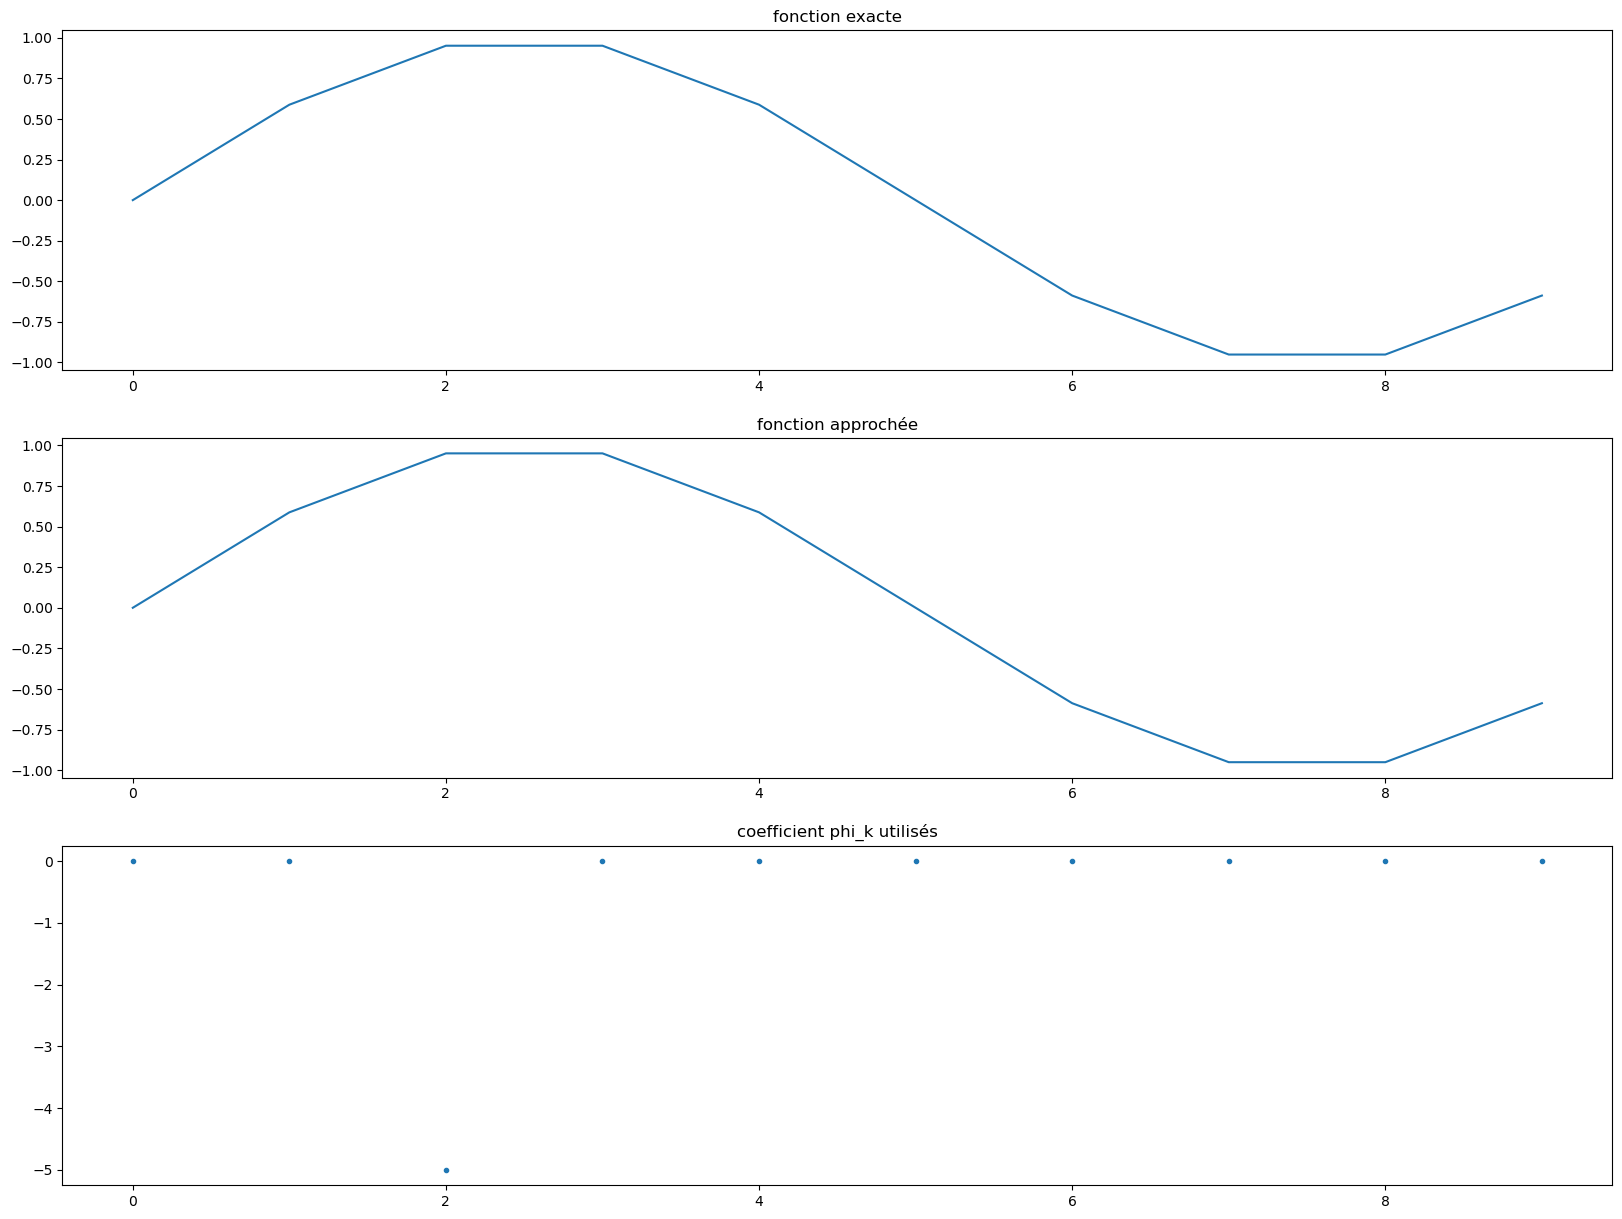

In [112]:
import numpy as np
from scipy.fftpack import rfft, irfft
from matplotlib import pyplot as plt
u = lambda x : np.sin(2*x*np.pi)
f = lambda x : -(4*np.pi**2)*np.sin(2*np.pi*x)+np.sin(2*np.pi*x)
lambda_2k = lambda k : ((2*np.pi*k)/(2*L))**2
lambda_2k_plus1 = lambda k : ((2*np.pi*(k+1))/(2*L))**2

N = 10
L = 1
dx = L/N
X = np.linspace(0.0,L-dx,N)
F = f(X)
F_chap = rfft(F)
U_chap = F_chap

U_chap = F_chap
for k in range(1, len(X)):
    if k % 2 == 0:
        U_chap[k] = F_chap[k] / (-lambda_2k(k) + 1) #* np.sin(2*np.pi * k/2 * (X/L)))
    else:
        U_chap[k] = F_chap[k] / (-lambda_2k_plus1(k) + 1)# * np.cos(2*np.pi*(k+1)/2*(X/L)))

#print(irfft(U_chap))

fig = plt.figure(figsize=(20, 15))
u_exacte = fig.add_subplot(311)
u_exacte.set_title("fonction exacte")
u_approche = fig.add_subplot(312)
u_approche.set_title("fonction approchée")
coeff_base = fig.add_subplot(313)
coeff_base.set_title("coefficient phi_k utilisés")

u_exacte.plot(u(X))
u_approche.plot(irfft(U_chap))


coeff_base.plot(np.arange(0,N),rfft(U),'.')


### Pour étudier la convergence il faudrait calculer l'erreur entre la fonction exacte et approchée, normaliser l'erreur et voir si sa pente est d'environ -2, c'est à dire que h est d'ordre 2. Attention à ne pas prendre une fonction qui est un élément de la base comme ici.

## 3. Problème d'évolution 1D

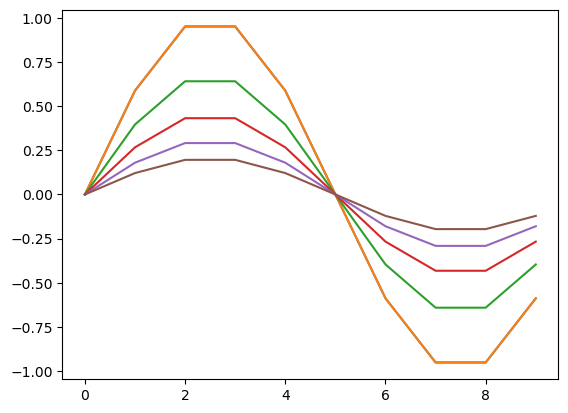

In [113]:
N = 20
L = 10
dx = L/N
x = np.linspace(dx/2, L-dx/2, N)
U = np.zeros(N)
U = U0(x, L)
U = u(X)
U_chap = rfft(U)
plt.plot(U)
for t in range(5):
    U_final = []
    for k, uk in enumerate(U_chap):
        if k % 2 == 0:
            U_final.append(uk * np.exp(-lambda_2k(k)* t))
        else:
            U_final.append(uk * np.exp(-lambda_2k_plus1(k)* t))

    U_final = irfft(U_final)
    plt.plot(U_final)